In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc
from sklearn.metrics import roc_auc_score

PROCESSED = Path("../data/processed")
REPORTS = Path("reports")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
prev = pd.read_parquet(PROCESSED / "previous_application.parquet")
train_target = pd.read_parquet(
    PROCESSED / "application_train_reduced.parquet",
    columns=["SK_ID_CURR", "TARGET"]
)

print(f"previous_application: {prev.shape}")
print(f"Memoria: {prev.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nDtypes:")
print(prev.dtypes.value_counts())
print(f"\nHead:")
print(prev.head(3))

previous_application: (1670214, 37)
Memoria: 1582.1 MB

Dtypes:
object     16
float32    10
float64     5
int32       3
int8        2
int16       1
Name: count, dtype: int64

Head:
   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  AMT_APPLICATION  \
0     2030495      271877     Consumer loans     1730.430          17145.0   
1     2802425      108129         Cash loans    25188.615         607500.0   
2     2523466      122040         Cash loans    15060.735         112500.0   

   AMT_CREDIT  AMT_DOWN_PAYMENT  AMT_GOODS_PRICE WEEKDAY_APPR_PROCESS_START  \
0     17145.0               0.0          17145.0                   SATURDAY   
1    679671.0               NaN         607500.0                   THURSDAY   
2    136444.5               NaN         112500.0                    TUESDAY   

   HOUR_APPR_PROCESS_START FLAG_LAST_APPL_PER_CONTRACT  \
0                       15                           Y   
1                       11                           Y   
2              

In [3]:
# 365243 en columnas DAYS_*
days_cols_p = [c for c in prev.columns if c.startswith("DAYS_")]
print(f"Columnas DAYS_*: {days_cols_p}\n")

for col in days_cols_p:
    n = (prev[col] == 365243).sum()
    if n > 0:
        print(f"  {col}: {n:,} centinelas 365243 ({100*n/len(prev):.2f}%)")
        prev[col] = prev[col].replace(365243, np.nan)

# XNA / XAP en categóricas
for col in prev.select_dtypes(include="object").columns:
    n_xna = (prev[col] == "XNA").sum()
    n_xap = (prev[col] == "XAP").sum()
    if n_xna + n_xap > 0:
        print(f"  {col}: XNA={n_xna:,}, XAP={n_xap:,}")
        prev[col] = prev[col].replace({"XNA": np.nan, "XAP": np.nan})

print("\nLimpieza completada.")

Columnas DAYS_*: ['DAYS_DECISION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']

  DAYS_FIRST_DRAWING: 934,444 centinelas 365243 (55.95%)
  DAYS_FIRST_DUE: 40,645 centinelas 365243 (2.43%)
  DAYS_LAST_DUE_1ST_VERSION: 93,864 centinelas 365243 (5.62%)
  DAYS_LAST_DUE: 211,221 centinelas 365243 (12.65%)
  DAYS_TERMINATION: 225,913 centinelas 365243 (13.53%)
  NAME_CONTRACT_TYPE: XNA=346, XAP=0
  NAME_CASH_LOAN_PURPOSE: XNA=677,918, XAP=922,661
  NAME_PAYMENT_TYPE: XNA=627,384, XAP=0
  CODE_REJECT_REASON: XNA=5,244, XAP=1,353,093
  NAME_CLIENT_TYPE: XNA=1,941, XAP=0
  NAME_GOODS_CATEGORY: XNA=950,809, XAP=0
  NAME_PORTFOLIO: XNA=372,230, XAP=0
  NAME_PRODUCT_TYPE: XNA=1,063,666, XAP=0
  NAME_SELLER_INDUSTRY: XNA=855,720, XAP=0
  NAME_YIELD_GROUP: XNA=517,215, XAP=0

Limpieza completada.


Clientes únicos en previous_application: 338,857
Solicitudes previas totales:              1,670,214
Clientes train con solicitudes previas:   291,057 (94.65%)

=== # solicitudes previas por cliente ===
count    338857.0
mean          4.9
std           4.2
min           1.0
25%           2.0
50%           4.0
75%           7.0
max          77.0
dtype: float64

Distribución (top 15):
1     60458
2     52737
3     45966
4     38159
5     30886
6     24588
7     19216
8     15085
9     11627
10     9063
11     6854
12     5214
13     4099
14     3206
15     2385
Name: count, dtype: int64


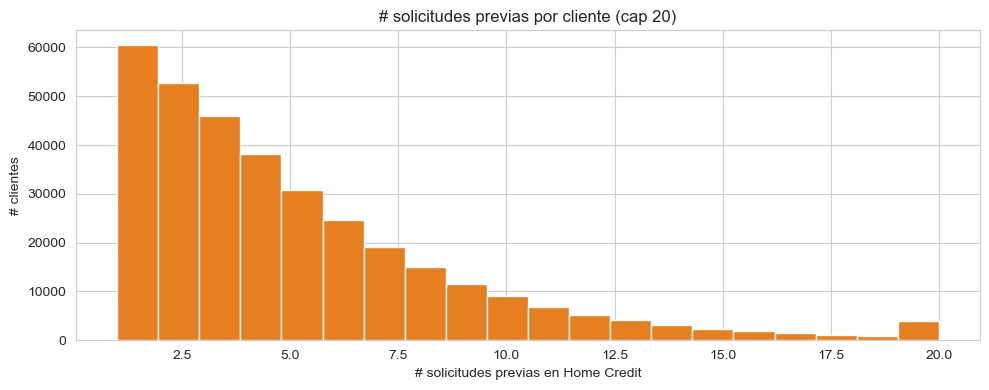

In [4]:
n_clients = prev["SK_ID_CURR"].nunique()
n_prevs = len(prev)
train_with_prev = train_target["SK_ID_CURR"].isin(prev["SK_ID_CURR"]).sum()

print(f"Clientes únicos en previous_application: {n_clients:,}")
print(f"Solicitudes previas totales:              {n_prevs:,}")
print(f"Clientes train con solicitudes previas:   {train_with_prev:,} "
      f"({100*train_with_prev/len(train_target):.2f}%)")

counts = prev.groupby("SK_ID_CURR").size()
print(f"\n=== # solicitudes previas por cliente ===")
print(counts.describe().round(1))
print(f"\nDistribución (top 15):")
print(counts.value_counts().sort_index().head(15))

fig, ax = plt.subplots(figsize=(10, 4))
counts.clip(upper=20).hist(bins=20, ax=ax, color="#e67e22")
ax.set_title("# solicitudes previas por cliente (cap 20)")
ax.set_xlabel("# solicitudes previas en Home Credit")
ax.set_ylabel("# clientes")
plt.tight_layout()
plt.savefig(REPORTS / "prev_per_client.png", dpi=80, bbox_inches="tight")
plt.show()

In [5]:
key_cats = ["NAME_CONTRACT_TYPE", "NAME_CONTRACT_STATUS", "NAME_CLIENT_TYPE",
            "NAME_PORTFOLIO", "NAME_PRODUCT_TYPE", "CODE_REJECT_REASON",
            "NAME_YIELD_GROUP"]

for col in key_cats:
    print(f"\n=== {col} ===")
    vc = prev[col].value_counts(dropna=False)
    pct = (vc / len(prev) * 100).round(2)
    print(pd.DataFrame({"count": vc, "pct": pct}).head(10))


=== NAME_CONTRACT_TYPE ===
                     count    pct
NAME_CONTRACT_TYPE               
Cash loans          747553  44.76
Consumer loans      729151  43.66
Revolving loans     193164  11.57
NaN                    346   0.02

=== NAME_CONTRACT_STATUS ===
                        count    pct
NAME_CONTRACT_STATUS                
Approved              1036781  62.07
Canceled               316319  18.94
Refused                290678  17.40
Unused offer            26436   1.58

=== NAME_CLIENT_TYPE ===
                    count    pct
NAME_CLIENT_TYPE                
Repeater          1231261  73.72
New                301363  18.04
Refreshed          135649   8.12
NaN                  1941   0.12

=== NAME_PORTFOLIO ===
                 count    pct
NAME_PORTFOLIO               
POS             691011  41.37
Cash            461563  27.63
NaN             372230  22.29
Cards           144985   8.68
Cars               425   0.03

=== NAME_PRODUCT_TYPE ===
                     count    p

In [6]:
num_cols_p = prev.select_dtypes(include=np.number).columns.tolist()
num_cols_p = [c for c in num_cols_p if c not in ("SK_ID_PREV", "SK_ID_CURR")]

print(f"=== Numéricas ({len(num_cols_p)}) ===")
print(prev[num_cols_p].describe().round(1))

print("\n=== % nulos ordenado ===")
nulls_p = (prev[num_cols_p].isna().mean() * 100).round(2).sort_values(ascending=False)
print(nulls_p)

=== Numéricas (19) ===
       AMT_ANNUITY  AMT_APPLICATION  AMT_CREDIT  AMT_DOWN_PAYMENT  \
count    1297979.0        1670214.0   1670213.0          774370.0   
mean       15955.1         175233.9    196114.0            6697.4   
std        14782.1         292779.8    318574.6           20921.5   
min            0.0              0.0         0.0              -0.9   
25%         6321.8          18720.0     24160.5               0.0   
50%        11250.0          71046.0     80541.0            1638.0   
75%        20658.4         180360.0    216418.5            7740.0   
max       418058.1        6905160.0   6905160.0         3060045.0   

       AMT_GOODS_PRICE  HOUR_APPR_PROCESS_START  NFLAG_LAST_APPL_IN_DAY  \
count        1284699.0                1670214.0               1670214.0   
mean          227847.3                     12.5                     1.0   
std           315396.6                      3.3                     0.1   
min                0.0                      0.0        

In [7]:
# Diferencia entre lo que pidió y lo que le aprobaron
prev["PREV_AMT_DIFF"] = prev["AMT_APPLICATION"] - prev["AMT_CREDIT"]
prev["PREV_AMT_RATIO"] = (prev["AMT_CREDIT"] / prev["AMT_APPLICATION"].replace(0, np.nan)).astype("float32")

print("=== AMT_APPLICATION vs AMT_CREDIT ===")
print(prev[["AMT_APPLICATION", "AMT_CREDIT", "PREV_AMT_DIFF", "PREV_AMT_RATIO"]].describe().round(2))

# % de solicitudes donde lo aprobado fue menor que lo pedido
n_reduced = (prev["PREV_AMT_DIFF"] > 0).sum()
print(f"\nSolicitudes donde aprobado < pedido: {n_reduced:,} ({100*n_reduced/len(prev):.2f}%)")

=== AMT_APPLICATION vs AMT_CREDIT ===
       AMT_APPLICATION  AMT_CREDIT  PREV_AMT_DIFF  PREV_AMT_RATIO
count       1670214.00  1670213.00     1670213.00      1277812.00
mean         175233.86   196114.02      -20880.06            1.03
std          292779.76   318574.62       71939.08            0.15
min               0.00        0.00    -1350000.00            0.00
25%           18720.00    24160.50      -12919.50            0.99
50%           71046.00    80541.00           0.00            1.00
75%          180360.00   216418.50           0.00            1.11
max         6905160.00  6905160.00     3020449.50           20.00

Solicitudes donde aprobado < pedido: 357,691 (21.42%)


In [8]:
agg_dict = {
    "SK_ID_PREV": "count",
    "AMT_APPLICATION": ["min", "max", "mean", "sum"],
    "AMT_CREDIT": ["min", "max", "mean", "sum"],
    "AMT_ANNUITY": ["min", "max", "mean"],
    "AMT_DOWN_PAYMENT": ["mean", "sum"],
    "AMT_GOODS_PRICE": ["mean", "sum"],
    "HOUR_APPR_PROCESS_START": ["mean"],
    "RATE_DOWN_PAYMENT": ["mean", "max"],
    "DAYS_DECISION": ["min", "max", "mean"],
    "CNT_PAYMENT": ["mean", "sum"],
    "PREV_AMT_DIFF": ["mean", "max"],
    "PREV_AMT_RATIO": ["mean", "min"],
}

prev_agg = prev.groupby("SK_ID_CURR").agg(agg_dict)
prev_agg.columns = ["PREV_" + "_".join(c).upper() for c in prev_agg.columns]
prev_agg = prev_agg.rename(columns={"PREV_SK_ID_PREV_COUNT": "PREV_N_APPS"})
prev_agg = prev_agg.reset_index()
print(f"prev_agg shape: {prev_agg.shape}")
print(prev_agg.head(3))

prev_agg shape: (338857, 29)
   SK_ID_CURR  PREV_N_APPS  PREV_AMT_APPLICATION_MIN  \
0      100001            1                   24835.5   
1      100002            1                  179055.0   
2      100003            3                   68809.5   

   PREV_AMT_APPLICATION_MAX  PREV_AMT_APPLICATION_MEAN  \
0                   24835.5                    24835.5   
1                  179055.0                   179055.0   
2                  900000.0                   435436.5   

   PREV_AMT_APPLICATION_SUM  PREV_AMT_CREDIT_MIN  PREV_AMT_CREDIT_MAX  \
0                   24835.5              23787.0              23787.0   
1                  179055.0             179055.0             179055.0   
2                 1306309.5              68053.5            1035882.0   

   PREV_AMT_CREDIT_MEAN  PREV_AMT_CREDIT_SUM  PREV_AMT_ANNUITY_MIN  \
0               23787.0              23787.0              3951.000   
1              179055.0             179055.0              9251.775   
2         

In [9]:
# Solicitudes aprobadas
approved = prev[prev["NAME_CONTRACT_STATUS"] == "Approved"].groupby("SK_ID_CURR").agg(
    PREV_APPROVED_COUNT=("SK_ID_PREV", "count"),
    PREV_APPROVED_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
    PREV_APPROVED_AMT_CREDIT_SUM=("AMT_CREDIT", "sum"),
)

# Solicitudes rechazadas
refused = prev[prev["NAME_CONTRACT_STATUS"] == "Refused"].groupby("SK_ID_CURR").agg(
    PREV_REFUSED_COUNT=("SK_ID_PREV", "count"),
)

# Solicitudes canceladas
canceled = prev[prev["NAME_CONTRACT_STATUS"] == "Canceled"].groupby("SK_ID_CURR").agg(
    PREV_CANCELED_COUNT=("SK_ID_PREV", "count"),
)

# Ofertas no usadas: aprobadas por el banco pero declinadas por el cliente
unused = prev[prev["NAME_CONTRACT_STATUS"] == "Unused offer"].groupby("SK_ID_CURR").agg(
    PREV_UNUSED_OFFER_COUNT=("SK_ID_PREV", "count"),
)

# Merges consecutivos a tu tablón principal de agregados
prev_agg = prev_agg.merge(approved, on="SK_ID_CURR", how="left")
prev_agg = prev_agg.merge(refused,  on="SK_ID_CURR", how="left")
prev_agg = prev_agg.merge(canceled, on="SK_ID_CURR", how="left")
prev_agg = prev_agg.merge(unused,   on="SK_ID_CURR", how="left")

# Conteos y montos nulos = 0 (para clientes que no tengan registros en estos estados)
cols_to_fillna = [
    "PREV_APPROVED_COUNT", "PREV_APPROVED_AMT_CREDIT_MEAN",
    "PREV_APPROVED_AMT_CREDIT_SUM", "PREV_REFUSED_COUNT",
    "PREV_CANCELED_COUNT", "PREV_UNUSED_OFFER_COUNT"
]
for col in cols_to_fillna:
    prev_agg[col] = prev_agg[col].fillna(0)

# Ratios relativas respecto al total de aplicaciones del cliente (PREV_N_APPS)
prev_agg["PREV_APPROVAL_RATE"] = (
    prev_agg["PREV_APPROVED_COUNT"] / prev_agg["PREV_N_APPS"]
).clip(0, 1).astype("float32")

prev_agg["PREV_REFUSAL_RATE"] = (
    prev_agg["PREV_REFUSED_COUNT"] / prev_agg["PREV_N_APPS"]
).clip(0, 1).astype("float32")

prev_agg["PREV_UNUSED_RATE"] = (
    prev_agg["PREV_UNUSED_OFFER_COUNT"] / prev_agg["PREV_N_APPS"]
).clip(0, 1).astype("float32")

print(f"Shape final: {prev_agg.shape}")
print(prev_agg.head(3))

Shape final: (338857, 38)
   SK_ID_CURR  PREV_N_APPS  PREV_AMT_APPLICATION_MIN  \
0      100001            1                   24835.5   
1      100002            1                  179055.0   
2      100003            3                   68809.5   

   PREV_AMT_APPLICATION_MAX  PREV_AMT_APPLICATION_MEAN  \
0                   24835.5                    24835.5   
1                  179055.0                   179055.0   
2                  900000.0                   435436.5   

   PREV_AMT_APPLICATION_SUM  PREV_AMT_CREDIT_MIN  PREV_AMT_CREDIT_MAX  \
0                   24835.5              23787.0              23787.0   
1                  179055.0             179055.0             179055.0   
2                 1306309.5              68053.5            1035882.0   

   PREV_AMT_CREDIT_MEAN  PREV_AMT_CREDIT_SUM  PREV_AMT_ANNUITY_MIN  \
0               23787.0              23787.0              3951.000   
1              179055.0             179055.0              9251.775   
2            

In [10]:
prev_target = prev_agg.merge(train_target, on="SK_ID_CURR", how="inner")
print(f"Clientes con previous_app + target: {prev_target.shape}")

prev_features = [c for c in prev_target.columns if c.startswith("PREV_")]
auc_list = []
for col in prev_features:
    m = prev_target[col].notna()
    if m.sum() == 0 or prev_target.loc[m, col].nunique() < 2:
        continue
    auc_raw = roc_auc_score(prev_target.loc[m, "TARGET"], prev_target.loc[m, col])
    auc_list.append({
        "feature": col,
        "auc": round(max(auc_raw, 1 - auc_raw), 4),
        "direction": "↓ menos default" if auc_raw < 0.5 else "↑ más default",
        "pct_null": round(100 * prev_target[col].isna().mean(), 2),
    })

auc_prev = pd.DataFrame(auc_list).sort_values("auc", ascending=False)
print(f"\n=== Top 25 features de previous_application por AUC ===")
print(auc_prev.head(25).to_string(index=False))
auc_prev.to_csv(REPORTS / "auc_rank_previous_app.csv", index=False)

Clientes con previous_app + target: (291057, 39)

=== Top 25 features de previous_application por AUC ===
                          feature    auc       direction  pct_null
         PREV_PREV_AMT_RATIO_MEAN 0.5729   ↑ más default      0.35
                PREV_REFUSAL_RATE 0.5602   ↑ más default      0.00
               PREV_APPROVAL_RATE 0.5589 ↓ menos default      0.00
          PREV_DAYS_DECISION_MEAN 0.5581   ↑ más default      0.00
           PREV_PREV_AMT_DIFF_MAX 0.5572 ↓ menos default      0.00
           PREV_DAYS_DECISION_MIN 0.5564   ↑ más default      0.00
               PREV_REFUSED_COUNT 0.5561   ↑ más default      0.00
        PREV_AMT_DOWN_PAYMENT_SUM 0.5555 ↓ menos default      0.00
          PREV_PREV_AMT_RATIO_MIN 0.5526   ↑ más default      0.35
       PREV_AMT_DOWN_PAYMENT_MEAN 0.5495 ↓ menos default      6.00
       PREV_RATE_DOWN_PAYMENT_MAX 0.5460 ↓ menos default      6.00
     PREV_APPROVED_AMT_CREDIT_SUM 0.5422 ↓ menos default      0.00
      PREV_RATE_DOWN_PA

In [11]:
prev_agg.to_parquet(PROCESSED / "previous_app_aggregated.parquet", index=False)
mem = prev_agg.memory_usage(deep=True).sum() / 1024**2
print(f"Guardado: previous_app_aggregated.parquet")
print(f"Shape: {prev_agg.shape} | Memoria: {mem:.1f} MB")

del prev, prev_target, approved, refused, canceled
gc.collect()

Guardado: previous_app_aggregated.parquet
Shape: (338857, 38) | Memoria: 81.4 MB


18